In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
file_path = '/content/drive/MyDrive/processed_fake_news_dataset.csv'

df = pd.read_csv(file_path, low_memory=False)

In [30]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())


Dataset Shape:
(44685, 6)

Columns:
Index(['title', 'text', 'subject', 'label', 'content', 'processed_text'], dtype='object')

First 5 Rows:


,title,text,subject,label,content,processed_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call circuit court committed coup ét...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,1,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,0,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,1,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...


In [31]:
# ==========================================================
# STEP 3 — DEFINE FEATURES AND TARGET
# ==========================================================

# X = Input feature
# We use processed text because
# it is already cleaned and normalized

X = df["processed_text"]


# y = Target label
#
# 0 = Fake News
# 1 = Real News

y = df["label"]


# ==========================================================
# DISPLAY BASIC INFORMATION
# ==========================================================

print("Features and Labels Created Successfully!")

print("\nNumber of News Articles:")
print(len(X))

print("\nLabel Distribution:")
print(y.value_counts())

Features and Labels Created Successfully!

Number of News Articles:
44685

Label Distribution:
label
0    23477
1    21208
Name: count, dtype: int64


# Step 4: TF-IDF Vectorization

## Objective
Machine Learning models cannot understand raw textual data directly. Therefore, the processed news text must be converted into numerical feature vectors before training.

## Why TF-IDF?

TF-IDF (Term Frequency–Inverse Document Frequency) is used to convert textual news content into weighted numerical values.

It works by:

- Assigning **higher importance** to words that occur frequently in a specific article.
- Assigning **lower importance** to words that are common across many articles.
- Reducing the impact of irrelevant and overly common words.

For example:

Common words such as:
- government
- people
- said

receive lower weights because they appear in many articles.

Rare but informative words such as:
- exposed
- shocking
- conspiracy

receive higher weights.

## Role in This Project

In this Fake News Detection system, TF-IDF helps identify important linguistic patterns between **fake news** and **real news**, making it easier for machine learning models to classify news articles accurately.

### Parameters Used
- **max_features = 5000** → Keeps the top 5000 most important words.
- **max_df = 0.7** → Removes overly common words.
- **min_df = 2** → Removes extremely rare words.

In [32]:
# ==========================================================
# STEP 4 — TF-IDF VECTORIZATION
# ==========================================================

# Create TF-IDF Vectorizer
#
# Role in project:
# Converts textual news data into
# numerical vectors for ML training

tfidf = TfidfVectorizer(

    # Keep top 5000 important words
    max_features=5000,

    # Ignore overly common words
    max_df=0.7,

    # Ignore extremely rare words
    min_df=2
)


# ==========================================================
# APPLY TF-IDF
# ==========================================================

X_tfidf = tfidf.fit_transform(X)


# ==========================================================
# DISPLAY RESULTS
# ==========================================================

print("TF-IDF Vectorization Completed!")

print("\nShape of TF-IDF Matrix:")
print(X_tfidf.shape)

TF-IDF Vectorization Completed!

Shape of TF-IDF Matrix:
(44685, 5000)


# Understanding TF-IDF Transformation

## Objective
To understand how textual news articles are converted into numerical values.

The TF-IDF vectorizer transforms a processed news article into a numerical representation where each word receives a weighted score.

### Higher Score
Words that:
- occur frequently in the article
- are rare across the dataset

receive higher TF-IDF values.

### Lower Score
Words that:
- are common in many articles

receive lower TF-IDF values.

For example:

In political news datasets, a word like **"Trump"** may receive a lower score because it appears frequently across many articles.

Whereas a rare word like **"coup"** or **"provocative"** may receive a higher score because it provides stronger contextual meaning.

This transformation allows machine learning models to understand textual patterns mathematically.

In [33]:
# ==========================================================
# STEP 4.1 — UNDERSTANDING TF-IDF CONVERSION
# ==========================================================

# Select one sample article
sample_index = 0

print("=" * 100)
print("ORIGINAL PROCESSED ARTICLE:\n")

print(X.iloc[sample_index][:1000])


# ==========================================================
# GET TF-IDF VECTOR OF SAME ARTICLE
# ==========================================================

# Convert sparse matrix row to array
sample_vector = X_tfidf[sample_index].toarray()[0]


# ==========================================================
# GET FEATURE (WORD) NAMES
# ==========================================================

feature_names = tfidf.get_feature_names_out()


# ==========================================================
# SHOW ONLY NON-ZERO WORDS
# (Important words present in article)
# ==========================================================

print("\n" + "=" * 100)
print("TF-IDF NUMERICAL REPRESENTATION:\n")

word_scores = []

# Loop through TF-IDF vector
for index, score in enumerate(sample_vector):

    # Show only words that exist in this article
    if score > 0:

        word_scores.append(
            (
                feature_names[index],
                score
            )
        )


# Sort by importance score
word_scores = sorted(
    word_scores,
    key=lambda x: x[1],
    reverse=True
)


# Display top 30 important words
print("Top TF-IDF Words in Article:\n")

for word, score in word_scores[:30]:

    print(f"{word:<20} --> {score:.4f}")

ORIGINAL PROCESSED ARTICLE:

ben stein call circuit court committed coup état constitution century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement circuit court washington state coup tat executive branch constitution stein went call judge seattle political puppet judiciary political pawn watch interview complete statement note stark contrast rhetoric leftist medium pundit neglect note court ever blocked presidential order immigration past discus legal efficacy halt actual text executive orderread trump news century wire trump filessupport work subscribing becoming member usnews

TF-IDF NUMERICAL REPRESENTATION:

Top TF-IDF Words in Article:

stein                --> 0.4906
circuit              --> 0.2095
coup                 --> 0.2039
halt                 --> 0.202

# Step 5: Train-Test Split

## Objective
To divide the dataset into training and testing datasets for proper model evaluation.

### Why Split the Dataset?

Training and testing on the same data can lead to **overfitting**, where the model memorizes patterns instead of learning general relationships.

Therefore, the dataset is divided into:

- **Training Data (80%)** → Used to train the model.
- **Testing Data (20%)** → Used to evaluate model performance on unseen data.

## Stratified Sampling

The parameter **stratify = y** is used to maintain the same proportion of fake and real news in both training and testing datasets.

This ensures fair and balanced model evaluation.

## Random State

**random_state = 42** is used to ensure reproducibility, meaning the same train-test split will be generated every time the notebook is executed.

In [34]:
# ==========================================================
# STEP 5 — TRAIN TEST SPLIT
# ==========================================================

# Purpose:
# We split the dataset into:
#
# Training Data (80%)
# → Used to teach/train the model
#
# Testing Data (20%)
# → Used to evaluate model performance
#
# This helps us check whether the model
# generalizes to unseen data.

X_train, X_test, y_train, y_test = train_test_split(

    X_tfidf,
    y,

    # 20% data for testing
    test_size=0.2,

    # Makes results reproducible
    random_state=42,

    # Maintains fake/real ratio
    stratify=y
)


# ==========================================================
# DISPLAY SHAPES
# ==========================================================

print("Train-Test Split Completed!")

print("\nTraining Feature Shape:")
print(X_train.shape)

print("\nTesting Feature Shape:")
print(X_test.shape)

print("\nTraining Labels Shape:")
print(y_train.shape)

print("\nTesting Labels Shape:")
print(y_test.shape)

Train-Test Split Completed!

Training Feature Shape:
(35748, 5000)

Testing Feature Shape:
(8937, 5000)

Training Labels Shape:
(35748,)

Testing Labels Shape:
(8937,)


# Step 6: Logistic Regression Model Training

## Objective
To train the Logistic Regression model for classifying news articles as **Fake News** or **Real News**.

## Why Logistic Regression?

Although the name contains the term **Regression**, Logistic Regression is a **classification algorithm**.

Since Fake News Detection involves two output classes:

- **0 → Fake News**
- **1 → Real News**

this problem is considered a **Binary Classification Problem**.

## Why Used in This Project?

Logistic Regression performs effectively on:

- High-dimensional data
- Sparse TF-IDF vectors
- Text classification problems

It is:
- Fast
- Efficient
- Easy to interpret
- Less prone to overfitting

Therefore, it serves as a strong baseline model for Fake News Detection.

## Model Training

The model is trained using the training dataset (`X_train`, `y_train`) to learn linguistic patterns and relationships between fake and real news articles.

In [35]:
# ==========================================================
# STEP 6 — TRAIN LOGISTIC REGRESSION MODEL
# ==========================================================

# Create Logistic Regression model
#
# Role in project:
# Logistic Regression is used for
# binary classification:
#
# 0 → Fake News
# 1 → Real News
#
# It performs well on sparse,
# high-dimensional TF-IDF data.

lr_model = LogisticRegression(

    # Maximum iterations
    # Increased to avoid convergence issues
    max_iter=1000,

    # Makes results reproducible
    random_state=42
)


# ==========================================================
# TRAIN MODEL
# ==========================================================

print("Training Logistic Regression Model...")

lr_model.fit(
    X_train,
    y_train
)

print("Model Training Completed!")

Training Logistic Regression Model...
Model Training Completed!


# Custom News Testing

## Objective
To test the trained Logistic Regression model on manually provided news articles.

Two custom news articles were tested:

1. **A real news article** related to Bengal Elections.
2. **A fake-style article** related to USA–Iran war misinformation.

## Purpose

This testing helps evaluate whether the model can classify completely unseen news content outside the dataset.

The model predicts:

- **Fake News**
- **Real News**

along with confidence probabilities.

This demonstrates the model’s practical usability in real-world fake news detection scenarios.

In [36]:
# ==========================================================
# TEST LOGISTIC REGRESSION ON CUSTOM NEWS
# ==========================================================

def predict_news(news_text):

    # Apply same TF-IDF transformation
    news_vector = tfidf.transform([news_text])

    # Predict
    prediction = lr_model.predict(news_vector)[0]

    # Confidence score
    probability = lr_model.predict_proba(news_vector)[0]

    # Output result
    if prediction == 0:
        print("Prediction: FAKE NEWS")
    else:
        print("Prediction: REAL NEWS")

    print("\nConfidence Scores:")
    print(f"Fake Probability: {probability[0]:.4f}")
    print(f"Real Probability: {probability[1]:.4f}")


# ==========================================================
# TEST ARTICLE
# Paste any article below
# ==========================================================

sample_news = """BREAKING: Iran Captures Elite U.S. Soldiers In Secret Desert Operation

A shocking overnight military operation has reportedly resulted in the capture of over 150 elite American soldiers by Iranian forces, according to viral social media reports. Anonymous sources claim that a secret U.S. mission near Tehran failed after Iran intercepted classified communications and launched surprise missile attacks.

Videos circulating online allegedly show captured American soldiers kneeling beside Iranian military officials while crowds celebrate in Tehran. However, U.S. authorities have remained silent, leading many online commentators to speculate that the government is hiding the truth from the public.

Experts claim this event could trigger a full-scale war between the United States and Iran in the coming days."""

predict_news(sample_news)

Prediction: FAKE NEWS

Confidence Scores:
Fake Probability: 0.9529
Real Probability: 0.0471


In [37]:
# ==========================================================
# TEST LOGISTIC REGRESSION ON CUSTOM NEWS
# ==========================================================

def predict_news(news_text):

    # Apply same TF-IDF transformation
    news_vector = tfidf.transform([news_text])

    # Predict
    prediction = lr_model.predict(news_vector)[0]

    # Confidence score
    probability = lr_model.predict_proba(news_vector)[0]

    # Output result
    if prediction == 0:
        print("Prediction: FAKE NEWS")
    else:
        print("Prediction: REAL NEWS")

    print("\nConfidence Scores:")
    print(f"Fake Probability: {probability[0]:.4f}")
    print(f"Real Probability: {probability[1]:.4f}")


# ==========================================================
# TEST ARTICLE
# Paste any article below
# ==========================================================

sample_news = """NEW DELHI, May 5 (Reuters) - An Indian chief minister ‌who was swept from power by Prime Minister Narendra Modi's Bharatiya Janata Party (BJP) in state elections said on Tuesday that she had "not been defeated" and would not resign, in an unprecedented political twist.
Modi's BJP defeated Chief ​Minister Mamata Banerjee's Trinamool Congress (TMC), which has been in power in West Bengal ​state since 2011, securing more than two-thirds of the 294 seats when votes were ⁠counted on Monday.
BJP has never ruled West Bengal, a populous eastern state that borders ​Bangladesh, and its victory is considered a political milestone as the party now controls almost all ​states in eastern India.
The TMC tally fell to 80 seats from its earlier 215, with Banerjee herself losing her seat.
Banerjee said about 100 seats were "forcibly taken" from her party, which also had to contend with a "biased" ​Election Commission. She did not back her accusation with evidence.
"I will not resign, I did not ​lose... officially, through the Election Commission, they (the BJP) can defeat us, but morally, we won the election," ‌she told ⁠a news briefing.
West Bengal's Chief Electoral Officer Manoj Kumar Agarwal termed the allegations "baseless". The BJP's Suvendu Adhikari, who defeated Banerjee, said "everything is mentioned in the constitution".
BANERJEE CAN APPEAL RESULT IN COURT
According to the Indian constitution, the state's governor can demand Banerjee's resignation or wait for her ​term to expire, after ​which newly elected lawmakers ⁠would be sworn in and the process of forming a new government would begin.
Banerjee's term is set to end on Thursday.
A defeated candidate ​in an Indian state election can challenge the result in court ​on grounds including ⁠corrupt practices, improper acceptance or rejection of nominations or votes, candidate disqualification, or non-compliance with election laws that affected the outcome.
Banerjee did not say if she would go to court.
Modi, his closest ⁠aide ​and Home Minister Amit Shah, and several senior BJP leaders ​campaigned for weeks in the state, focusing on what they called illegal immigration from Bangladesh and the weak local ​economy under Banerjee."""

predict_news(sample_news)

Prediction: REAL NEWS

Confidence Scores:
Fake Probability: 0.0182
Real Probability: 0.9818


# Step 7: Prediction on Test Dataset

## Objective
To generate predictions using the trained Logistic Regression model.

The trained model is applied to the unseen testing dataset (`X_test`) to predict whether each news article is:

- **Fake News (0)**
- **Real News (1)**

The predicted labels are stored in `y_pred`.

These predictions are later compared with the actual labels (`y_test`) to evaluate model performance.

In [38]:
# ==========================================================
# STEP 7 — MAKE PREDICTIONS
# ==========================================================

# Predict labels for test dataset

y_pred = lr_model.predict(X_test)


# ==========================================================
# DISPLAY SAMPLE PREDICTIONS
# ==========================================================

print("Predictions Completed!")

print("\nFirst 10 Predictions:")
print(y_pred[:10])

Predictions Completed!

First 10 Predictions:
[1 1 1 0 1 0 0 0 0 1]


# Step 8: Model Evaluation

## Objective
To evaluate the performance of the Logistic Regression model using multiple classification metrics.

### Why Multiple Metrics?

Accuracy alone may not fully explain model performance, especially in classification problems.

Therefore, additional metrics are used.

## Evaluation Metrics Used

### Accuracy
Measures the overall percentage of correct predictions.

### Precision
Measures how many predicted labels were actually correct.

### Recall
Measures how effectively the model identifies actual classes.

### F1-Score
Provides a balanced measure of Precision and Recall.

These metrics collectively provide a more reliable understanding of model performance.

In [39]:
# ==========================================================
# STEP 8 — MODEL EVALUATION
# ==========================================================

# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)


# ==========================================================
# DISPLAY RESULTS
# ==========================================================

print("=" * 50)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 50)

print(f"\nAccuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1-Score  : {f1:.4f}")

LOGISTIC REGRESSION PERFORMANCE

Accuracy  : 0.9909
Precision : 0.9871
Recall    : 0.9939
F1-Score  : 0.9905


# Overfitting Analysis

## Objective
To determine whether the model is overfitting.

### What is Overfitting?

Overfitting occurs when a model performs extremely well on training data but poorly on unseen testing data.

To verify this, training accuracy and testing accuracy are compared.

### Observation

The difference between training and testing accuracy was minimal.

This indicates that:

- The model generalized well
- The model learned meaningful patterns
- Significant overfitting did not occur

Therefore, the Logistic Regression model demonstrates strong reliability on unseen data.

In [40]:
# ==========================================================
# STEP 9 — CHECK OVERFITTING
# ==========================================================

# Training accuracy
train_accuracy = lr_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = lr_model.score(
    X_test,
    y_test
)


print("=" * 50)
print("OVERFITTING CHECK")
print("=" * 50)

print(f"\nTraining Accuracy : {train_accuracy:.4f}")

print(f"Testing Accuracy  : {test_accuracy:.4f}")


# Difference between train & test
difference = train_accuracy - test_accuracy

print(f"\nDifference : {difference:.4f}")

OVERFITTING CHECK

Training Accuracy : 0.9935
Testing Accuracy  : 0.9909

Difference : 0.0025


# Step 10.1: Confusion Matrix

## Objective
To analyze prediction correctness in greater detail.

A Confusion Matrix helps visualize:

- Correct Predictions
- Incorrect Predictions
- Type of classification errors

### Components

#### True Positive (TP)
Real News correctly predicted as Real.

#### True Negative (TN)
Fake News correctly predicted as Fake.

#### False Positive (FP)
Fake News incorrectly predicted as Real.

#### False Negative (FN)
Real News incorrectly predicted as Fake.

## Importance in Fake News Detection

The Confusion Matrix is important because it reveals the nature of prediction errors.

For example:

Incorrectly classifying **Fake News as Real News** can be more dangerous since misinformation may spread.

Thus, the Confusion Matrix provides deeper insight beyond simple accuracy.

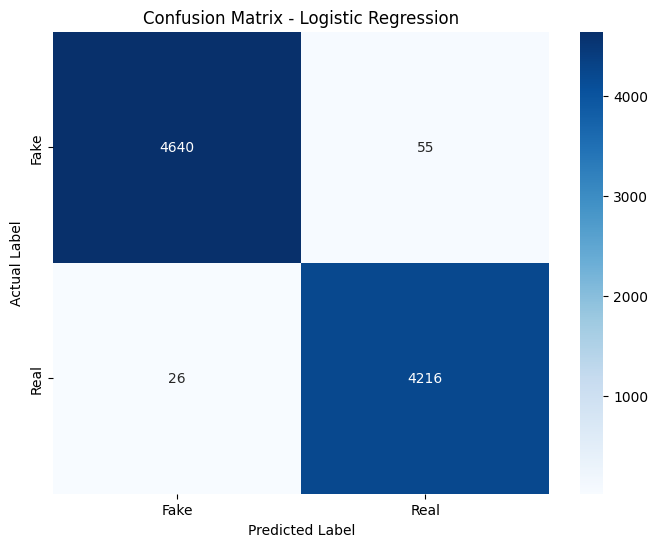

In [41]:
# ==========================================================
# STEP 10.1 — CONFUSION MATRIX
# ==========================================================

# Import visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================================
# CREATE CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


# ==========================================================
# PLOT CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,

    annot=True,
    fmt='d',

    cmap='Blues',

    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

# Step 10.2: Classification Report

## Objective
To obtain a detailed performance summary of the Logistic Regression model.

The Classification Report provides:

- Precision
- Recall
- F1-Score
- Support

for each class separately.

### Fake News Class
Shows performance in identifying fake news.

### Real News Class
Shows performance in identifying real news.

### Support
Represents the number of samples belonging to each class.

This report provides a complete evaluation of model classification quality.

In [42]:
# ==========================================================
# STEP 10.2 — CLASSIFICATION REPORT
# ==========================================================

print("=" * 60)

print("CLASSIFICATION REPORT")

print("=" * 60)


print(
    classification_report(
        y_test,
        y_pred,

        target_names=[
            "Fake News",
            "Real News"
        ]
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Fake News       0.99      0.99      0.99      4695
   Real News       0.99      0.99      0.99      4242

    accuracy                           0.99      8937
   macro avg       0.99      0.99      0.99      8937
weighted avg       0.99      0.99      0.99      8937

